In [1]:

#%% Run to have everything 

import torch
from numpy import random
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath("../tgv_pycuda-master"))
sys.path.append(os.path.abspath("../tgv_odl_pghd/denoise"))
sys.path.append(os.path.abspath(".."))




from Algo_setuptorch import Params

from data.dataset import build_train_test_data


from algorithm.unrolled_model import UnrolledFBS
from training.train import train
from NN.plots import *
from NN.run import *


from denoise_pycuda import tgv_denoise

from pghd_denoising import pdhg






device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

params = Params()

TRAIN_SEEDS = list(range(50))  
TEST_SEEDS = list(range(50,60))


size = params.size
SHAPES = [
    (1, 1, size, size),
    (1, 2, size, size),
    (1, 2, size, size),
    (1, 3, size, size),
]
N_CH = sum(s[1] for s in SHAPES)
N_CH_primal = sum(s[1] for s in SHAPES[:2])
print("ok")

train_data, test_data = build_train_test_data(
    train_seeds=TRAIN_SEEDS,
    test_seeds=TEST_SEEDS,
    params=params,
    device=device,
)


initial_state, clean, functions = test_data[0]

Device: cuda
ok


In [2]:

model = UnrolledFBS(
    params=params,
    shapes=SHAPES,
    n_channels=N_CH_primal,
    T=10,
    alpha=0.99,
).to(device).float()

model.load_state_dict(torch.load("model_final_10.pt", map_location="cpu"))

model.eval()
 

UnrolledFBS(
  (dev_net): DeviationNet(
    (input_norm): InstanceNorm2d(21, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (body): Sequential(
      (0): ConvBlock(
        (conv): Conv2d(21, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      )
      (1): ConvBlock(
        (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      )
    )
    (final): Conv2d(32, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)

In [3]:
F_vals_0, res_0= run_zero(initial_state,functions, params, SHAPES, 100, device)
F_vals,res ,history= run_learned(model,initial_state,clean,functions,T_test=100,return_all=True)
import matplotlib.pyplot as plt
print(F_vals)
img = history["x"][-1][0]

# convertir proprement
img_np = img.detach().cpu().squeeze().numpy()

plt.imsave("final_image.png", img_np, cmap="gray")

iter:0
362.8879089355469
iter:1
336.962646484375
iter:2
307.0479431152344
iter:3
277.60113525390625
iter:4
252.46405029296875
iter:5
235.641845703125
iter:6
233.20343017578125
iter:7
244.56961059570312
iter:8
257.9014892578125
iter:9
265.34588623046875
iter:10
265.6603698730469
iter:11
260.6523132324219
iter:12
253.16241455078125
iter:13
245.806884765625
iter:14
239.7576904296875
iter:15
235.13772583007812
iter:16
231.76776123046875
iter:17
229.30728149414062
iter:18
227.24777221679688
iter:19
224.93992614746094
iter:20
221.86160278320312
iter:21
217.92843627929688
iter:22
213.49618530273438
iter:23
209.19436645507812
iter:24
205.42437744140625
iter:25
202.5496063232422
iter:26
200.64895629882812
iter:27
199.50125122070312
iter:28
198.8617401123047
iter:29
198.34214782714844
iter:30
197.73004150390625
iter:31
196.77359008789062
iter:32
195.44204711914062
iter:33
193.78018188476562
iter:34
191.89077758789062
iter:35
189.8236541748047
iter:36
187.68069458007812
iter:37
185.59072875976562

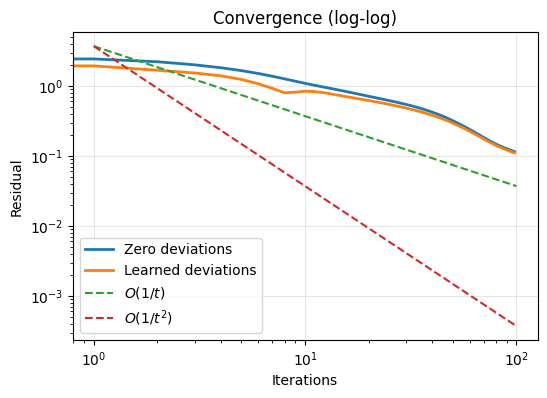

In [4]:

# Convertir en numpy si besoin
res_0 = np.array(res_0)
res = np.array(res)

# Axe des itérations 
iters = np.arange(1, len(res_0) + 1)

plt.figure(figsize=(6,4))

# Courbes principales

plt.loglog(res_0[1:], label='Zero deviations', linewidth=2)
plt.loglog(res[1:], label='Learned deviations', linewidth=2)
# Références théoriques
plt.loglog(iters, res_0[0]/iters, '--', label=r'$O(1/t)$')
plt.loglog(iters, res_0[0]/iters**2, '--', label=r'$O(1/t^2)$')

plt.xlabel('Iterations')
plt.ylabel('Residual')
plt.title('Convergence (log-log)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

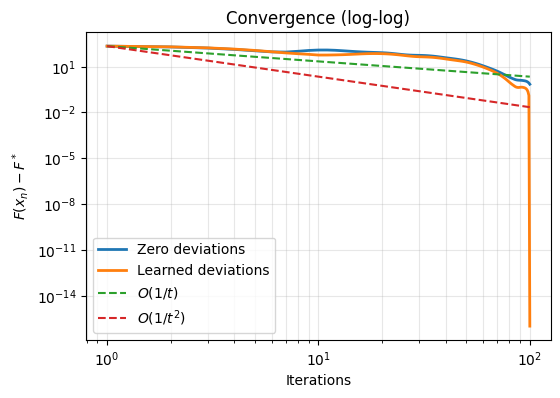

In [ ]:
# convertir proprement
F_vals_0 = np.array([
    f.detach().cpu().item() if torch.is_tensor(f) else f
    for f in F_vals_0
])

F_vals = np.array([
    f.detach().cpu().item() if torch.is_tensor(f) else f
    for f in F_vals
])

# approx de F*
F_star = min(F_vals_0.min(), F_vals.min())

# gaps
gap_0 = F_vals_0 - F_star
gap   = F_vals   - F_star

# éviter log(0)
gap_0 = np.maximum(gap_0, 1e-16)
gap   = np.maximum(gap,   1e-16)

gap_0 = gap_0[:90]
gap   =gap[:90]


iters = np.arange(1, len(gap_0) + 1)

plt.figure(figsize=(6,4))

plt.loglog(iters, gap_0, label='Zero deviations', linewidth=2)
plt.loglog(iters, gap,   label='Learned deviations', linewidth=2)

# références
plt.loglog(iters, gap_0[0]/iters, '--', label=r'$O(1/t)$')
plt.loglog(iters, gap_0[0]/iters**2, '--', label=r'$O(1/t^2)$')

plt.xlabel('Iterations')
plt.ylabel(r'$F(x_n) - F^*$')
plt.title('Convergence (log-log)')
plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.show()

In [6]:

data = initial_state.detach().cpu().squeeze().numpy()

x, F_vals_pdhg = pdhg(data)

F_vals_learned,res_learned = run_learned(model,initial_state,clean,functions,T_test=500)

gaps = np.array(F_vals_pdhg) - min(F_vals_pdhg)
gaps_learned = np.array(F_vals_learned) - min(F_vals_learned)

gaps=gaps[:1000]
gaps_learned=gaps_learned[:1000]

iter = 0
Iter 1: F(x) = 106.268896
iter = 1
Iter 2: F(x) = 104.216956
iter = 2
Iter 3: F(x) = 101.117548
iter = 3
Iter 4: F(x) = 97.208053
iter = 4
Iter 5: F(x) = 92.773471
iter = 5
Iter 6: F(x) = 88.074683
iter = 6
Iter 7: F(x) = 83.321091
iter = 7
Iter 8: F(x) = 78.549572
iter = 8
Iter 9: F(x) = 73.765371
iter = 9
Iter 10: F(x) = 69.039960
iter = 10
Iter 11: F(x) = 64.446606
iter = 11
Iter 12: F(x) = 60.094317
iter = 12
Iter 13: F(x) = 56.088270
iter = 13
Iter 14: F(x) = 52.462138
iter = 14
Iter 15: F(x) = 49.223777
iter = 15
Iter 16: F(x) = 46.414303
iter = 16
Iter 17: F(x) = 44.082650
iter = 17
Iter 18: F(x) = 42.236409
iter = 18
Iter 19: F(x) = 40.858195
iter = 19
Iter 20: F(x) = 39.925762
iter = 20
Iter 21: F(x) = 39.409328
iter = 21
Iter 22: F(x) = 39.254613
iter = 22
Iter 23: F(x) = 39.404951
iter = 23
Iter 24: F(x) = 39.800970
iter = 24
Iter 25: F(x) = 40.395182
iter = 25
Iter 26: F(x) = 41.130032
iter = 26
Iter 27: F(x) = 41.954828
iter = 27
Iter 28: F(x) = 42.822625
iter = 2

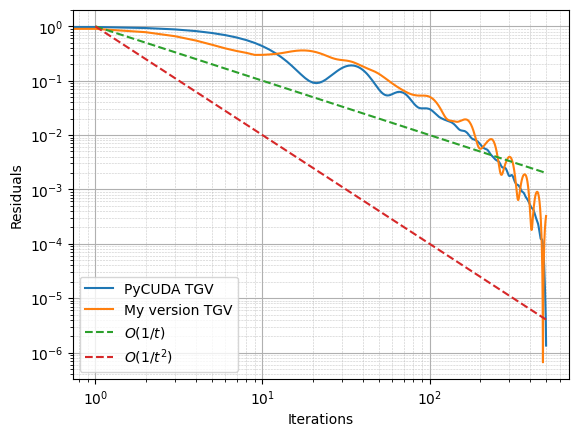

In [7]:

gaps = gaps[gaps > 1e-12]
gaps_learned = gaps_learned[gaps_learned > 1e-12]
gaps /= gaps[0]
gaps_learned /= gaps_learned[0]
N = min(len(gaps), len(gaps_learned))
t = np.arange(1, N + 1)

plt.loglog(gaps[:N], label="PyCUDA TGV")
plt.loglog(gaps_learned[:N], label="My version TGV")




ref1 = 1/ t         # O(1/t)
ref2 = 1 / (t**2)    # O(1/t^2)

plt.loglog(t, ref1, '--', label=r'$O(1/t)$')
plt.loglog(t, ref2, '--', label=r'$O(1/t^2)$') 

plt.xlabel("Iterations")
plt.ylabel("Residuals")
plt.legend()
plt.minorticks_on()  # active les sous-graduations
plt.grid(which='major', linestyle='-', linewidth=0.8)
plt.grid(which='minor', linestyle='--', linewidth=0.4, alpha=0.7)

plt.savefig("energy.pdf")
plt.show()  